# Notebook 2: Understanding VAEs for Brain Decoding

Before we can decode brain activity into images, we need to understand the representation we'll be predicting. This notebook introduces **Variational Autoencoders (VAEs)**—the compression backbone that makes brain-to-image reconstruction tractable.

The core problem is dimensionality. A 256×256 image has nearly 200,000 pixel values, but we only have ~8,000 training examples. Predicting pixels directly is hopeless. VAEs solve this by compressing images into a 4,096-dimensional latent space—a 48× reduction that preserves perceptually meaningful structure while discarding redundant detail.

We'll explore how VAEs encode and decode images, why their latent space is well-suited for regression, and how reconstruction quality guides the next steps. By the end, you'll understand exactly what we're asking the brain decoder to predict in the next notebook.

In [7]:
# Pinned setup for Long-Term Reproduciblity (Notebook 2)

import os
import random
import subprocess
import sys
import importlib.metadata as md

SEED = 42

PINNED_PACKAGES = [
    "webdataset==0.2.86",
    "braceexpand==0.1.7",
    "diffusers==0.31.0",
    "transformers==4.46.3",
    "accelerate==1.1.1",
    "safetensors==0.4.5",
    "huggingface_hub==0.26.5",
]

subprocess.check_call([
    sys.executable, "-m", "pip", "install", "-q",
    "--upgrade-strategy", "only-if-needed",
    *PINNED_PACKAGES
])

import numpy as np
import torch

os.environ["PYTHONHASHSEED"] = str(SEED)
os.environ["CUBLAS_WORKSPACE_CONFIG"] = ":4096:8"

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False
torch.use_deterministic_algorithms(True, warn_only=True)

print(f"numpy runtime version: {np.__version__}")
print(f"torch runtime version: {torch.__version__}")

for package in PINNED_PACKAGES:
    name = package.split("==")[0].replace("_", "-")
    print(f"{name}=={md.version(name)}")

print("Notebook 2 setup complete")



numpy runtime version: 2.0.2
torch runtime version: 2.10.0+cpu
webdataset==0.2.86
braceexpand==0.1.7
diffusers==0.31.0
transformers==4.46.3
accelerate==1.1.1
safetensors==0.4.5
huggingface-hub==0.26.5
Notebook 2 setup complete


## Key libraries

This notebook uses **PyTorch** for tensor operations and GPU compute, **diffusers** to load pre-trained VAE models from the Stable Diffusion family, and **matplotlib** for visualization.

In [8]:
# Standard libraries
import io
from pathlib import Path

# Numeric + PyTorch
import torch.nn.functional as F

# VAE from diffusers
from diffusers import AutoencoderKL

# Dataset streaming
import webdataset as wds
import braceexpand
from PIL import Image

# Visualization
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


## Part 1: What is a Variational Autoencoder (VAE)?

A **Variational Autoencoder** is a neural network that learns to compress and reconstruct data. It consists of three components that work together: an encoder, a latent space, and a decoder.

The **encoder** takes an input image and compresses it into a latent vector. Think of it as summarizing an image into its most essential features.

Mathematically, $\text{Encoder}: \mathbf{x} \rightarrow (\boldsymbol{\mu}, \boldsymbol{\sigma})$. The encoder outputs a *distribution* over latents (mean $\mu$ and standard deviation $\sigma$), not just a single point.

The **latent space** is the compressed representation where similar images map to nearby points. For the SD-VAE we use here, a `256×256×3` input image (196,608 values) becomes a `32×32×4` latent tensor (4,096 values)—a **48× compression**. The latent space preserves perceptually important features while discarding redundant pixel-level details.

The **decoder** reconstructs an image from a latent vector: $\text{Decoder}: \mathbf{z} \rightarrow \hat{\mathbf{x}}$. The reconstruction $\hat{\mathbf{x}}$ should look like the original $\mathbf{x}$, but it won't be pixel-perfect.

```
Image (256×256×3) → [Encoder] → Latent (32×32×4) → [Decoder] → Reconstruction (256×256×3)
   196,608 values              4,096 values                   196,608 values
```

The VAE is trained to minimize reconstruction error while keeping the latent space well-organized (regularized). This balance is what makes VAEs useful for generative modeling.

In [9]:
# Configuration
VAE_ID = "stabilityai/sd-vae-ft-mse"  # Same VAE as Tutorial 1
IMG_SIZE = 256

# Paths
PROJECT_DIR = Path.cwd().parent  # Go up from Notebooks/ to project root
CACHE_DIR = PROJECT_DIR / "cache"
CACHE_DIR.mkdir(parents=True, exist_ok=True)

print(f"VAE: {VAE_ID}")
print(f"Image size: {IMG_SIZE}×{IMG_SIZE}")
print(f"Cache directory: {CACHE_DIR}")

VAE: stabilityai/sd-vae-ft-mse
Image size: 256×256
Cache directory: /cache


In [10]:
# Load the Stable Diffusion VAE
print("Loading VAE...")
vae = AutoencoderKL.from_pretrained(VAE_ID).to(device).eval()

# Print architecture summary
print(f"\nVAE Architecture:")
print(f"  Scaling factor: {vae.config.scaling_factor}")
print(f"  Latent channels: {vae.config.latent_channels}")
print(f"  Input: {IMG_SIZE}×{IMG_SIZE}×3 → Latent: {IMG_SIZE//8}×{IMG_SIZE//8}×{vae.config.latent_channels}")

latent_dim = (IMG_SIZE // 8) * (IMG_SIZE // 8) * vae.config.latent_channels
pixel_dim = IMG_SIZE * IMG_SIZE * 3
print(f"  Compression: {pixel_dim:,} pixels → {latent_dim:,} latents ({pixel_dim/latent_dim:.1f}× reduction)")

Loading VAE...

VAE Architecture:
  Scaling factor: 0.18215
  Latent channels: 4
  Input: 256×256×3 → Latent: 32×32×4
  Compression: 196,608 pixels → 4,096 latents (48.0× reduction)


## Part 2: Why Use SD-VAE Latents for Brain Decoding?

In natural stimulus reconstruction, our ultimate goal is to create a faithful reconstruction of the ground truth image (the image the participant saw while they were in the fMRI machine). So why even bother with some compression algorithm? Why not just predict the pixels directly?

The first problem is **dimensionality**. A `256×256×3` RGB image has **196,608 dimensions**. In the NSD dataset, we have approximately ~8,000 training samples (images shown to a subject) and ~15,000 voxels (fMRI measurements per image). This means we're trying to learn a mapping from 15,000 inputs to 196,608 outputs with only 8,000 examples. This is **severely underconstrained**—we have far more parameters to learn than training samples. Regularization (like Ridge regression) helps, but you're fundamentally fighting an uphill battle. Imagine trying to predict 200,000 numbers from 15,000 numbers, but you only have 8,000 examples to learn from. For every output dimension, you need to learn which input voxels matter and how much. With so few examples, the model will overfit to noise rather than learning meaningful patterns.

The second problem is that **pixel space is perceptually harsh**. Mean Squared Error (MSE) in pixel space penalizes tiny spatial shifts severely. A reconstruction that's shifted by just 1 pixel looks **fine to humans** but has **huge MSE** because every pixel is technically "wrong." Meanwhile, an image with completely wrong colors but perfect alignment might have lower MSE despite looking terrible. This mismatch between perceptual quality and mathematical loss makes pixel-space regression frustrating—your loss can be high even when reconstructions look good.


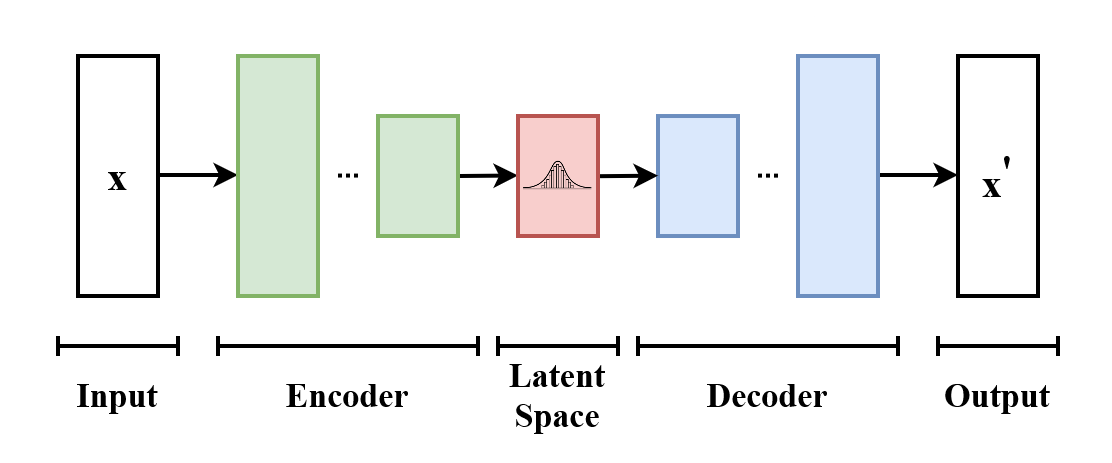



The solution is to predict **VAE latents** instead. By predicting latents (4,096 dimensions) instead of pixels (196,608 dimensions), we reduce the target dimensionality by 48×, going from 0.04 samples per dimension to nearly 2 samples per dimension. The latent space is also **perceptually organized**: images that look similar to humans have similar latent representations. This means small errors in latent space correspond to small perceptual errors, unlike pixel space where small spatial shifts cause large losses. Additionally, latents have partial spatial invariance which allows small shifts in the image to get absorbed rather than cause catastrophic loss increases.

Mathematically, in pixel-space regression we would learn $f_\theta: \mathbf{v} \rightarrow \hat{\mathbf{x}} \in \mathbb{R}^{196608}$, but in latent-space regression we learn $g_\phi: \mathbf{v} \rightarrow \hat{\mathbf{z}} \in \mathbb{R}^{4096}$ and then apply the pre-trained decoder: $\hat{\mathbf{x}} = \text{VAE.decode}(\hat{\mathbf{z}})$. The regression problem $g_\phi$ is **48× easier** than $f_\theta$ because we're predicting far fewer values, and each latent dimension captures meaningful information.

The trade-off is that your reconstructions must pass through the VAE decoder. This means that even with perfect latent prediction, $\text{VAE.decode}(\text{VAE.encode}(\mathbf{x})) \neq \mathbf{x}$. In practice however, the difference is largely indistinguishable as we'll see in Part 4, and more than good enough for our purposes in most cases.

## Part 3: Loading NSD Images

Before we demonstrate the VAE, we need real images. We'll use the Natural Scenes Dataset (NSD), streaming a small subset directly from HuggingFace. This is the same dataset used in Tutorial 1 for brain decoding.

In [11]:
# Helper functions for encoding and decoding

def to_vae_range(images: torch.Tensor) -> torch.Tensor:
    """
    Convert images to VAE input range [-1, 1].
    Handles both uint8 [0,255] and float [0,1] inputs.
    """
    x = images.float()
    if x.max() > 1.5:  # uint8 input
        x = x / 255.0
    x = x.clamp(0, 1)
    x = x * 2 - 1  # [0,1] -> [-1,1]
    return x


@torch.inference_mode()
def encode_to_latents(images: torch.Tensor, vae: AutoencoderKL) -> torch.Tensor:
    """
    Encode images to scaled SD-VAE latents.

    Args:
        images: [B, 3, H, W] tensor in [0,1] or [0,255]
        vae: Loaded AutoencoderKL model

    Returns:
        latents: [B, 4, H/8, W/8] scaled latents
    """
    scaling_factor = float(vae.config.scaling_factor)

    x = to_vae_range(images).to(device)

    # Resize if needed
    if x.shape[-2:] != (IMG_SIZE, IMG_SIZE):
        x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

    # Encode to latent distribution and take the mode (deterministic)
    latent_dist = vae.encode(x).latent_dist
    latents = latent_dist.mode() * scaling_factor

    return latents.cpu()


@torch.inference_mode()
def decode_from_latents(latents: torch.Tensor, vae: AutoencoderKL) -> torch.Tensor:
    """
    Decode scaled SD-VAE latents back to images.

    Args:
        latents: [B, 4, H/8, W/8] scaled latents
        vae: Loaded AutoencoderKL model

    Returns:
        images: [B, 3, H, W] in [0, 1]
    """
    scaling_factor = float(vae.config.scaling_factor)

    z = latents.to(device) / scaling_factor
    x = vae.decode(z).sample
    x = (x.clamp(-1, 1) + 1) / 2  # [-1,1] -> [0,1]

    return x.cpu()


print("Encoding/decoding functions defined.")

Encoding/decoding functions defined.


In [12]:
# Load NSD images via streaming (same approach as Tutorial 1)

def load_nsd_images(subject_id: int = 1, max_samples: int = 100):
    """
    Stream NSD images from HuggingFace.
    Returns images as a tensor [N, 3, H, W] in [0, 1] range.
    """
    base_url = "https://huggingface.co/datasets/pscotti/naturalscenesdataset/resolve/main/webdataset_avg_new"
    url_pattern = f"{base_url}/train/train_subj0{subject_id}_{{0..2}}.tar"  # First 3 shards
    urls = list(braceexpand.braceexpand(url_pattern))

    print(f"Loading NSD images for Subject {subject_id}...")
    dataset = wds.WebDataset(urls)

    images_list = []
    for sample in dataset:
        # Decode image
        img = Image.open(io.BytesIO(sample['jpg'])).convert('RGB')
        img_tensor = torch.from_numpy(np.array(img)).permute(2, 0, 1).float() / 255.0
        images_list.append(img_tensor)

        if len(images_list) % 25 == 0:
            print(f"  Loaded {len(images_list)} images...")

        if len(images_list) >= max_samples:
            break

    images = torch.stack(images_list)
    print(f"  Done! Loaded {len(images)} images, shape: {images.shape}")
    return images


# Load a small batch for demonstration
nsd_images = load_nsd_images(subject_id=1, max_samples=50)
print(f"\nNSD images shape: {nsd_images.shape}")
print(f"Value range: [{nsd_images.min():.3f}, {nsd_images.max():.3f}]")

Loading NSD images for Subject 1...
  Loaded 25 images...
  Loaded 50 images...
  Done! Loaded 50 images, shape: torch.Size([50, 3, 224, 224])

NSD images shape: torch.Size([50, 3, 224, 224])
Value range: [0.000, 1.000]


## Part 4: Seeing the VAE in Action

Now that we have our NSD images loaded, let's see how the VAE actually performs. We'll pass images through the encoder to get latents, then decode those latents back into images. This round-trip will show us exactly what information the VAE preserves and what it discards, which directly determines the brain decoder's performance.

In [13]:
# Encode and decode the first few NSD images
test_images = nsd_images[:4]  # Use first 4 for visualization

print("Encoding images to latents...")
latents = encode_to_latents(test_images, vae)
print(f"Latent shape: {latents.shape}")
print(f"Latent stats: mean={latents.mean():.3f}, std={latents.std():.3f}")

print("\nDecoding latents back to images...")
reconstructions = decode_from_latents(latents, vae)
print(f"Reconstruction shape: {reconstructions.shape}")

Encoding images to latents...
Latent shape: torch.Size([4, 4, 32, 32])
Latent stats: mean=0.077, std=0.906

Decoding latents back to images...
Reconstruction shape: torch.Size([4, 3, 256, 256])


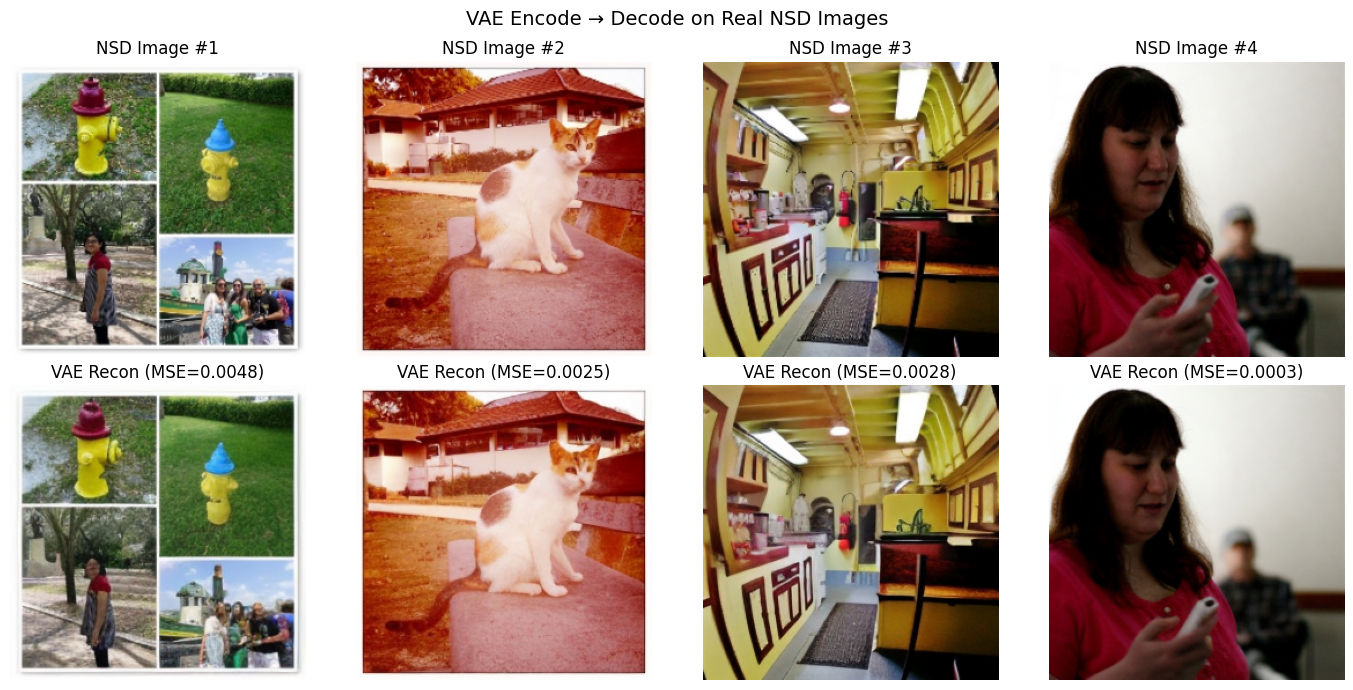

In [14]:
# Visualize: Original vs Reconstruction
fig, axes = plt.subplots(2, 4, figsize=(14, 7))

# Resize originals to match reconstruction size for fair comparison
test_images_resized = F.interpolate(test_images, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

for i in range(4):
    # Original (show resized version for consistency)
    axes[0, i].imshow(test_images_resized[i].permute(1, 2, 0).clamp(0, 1))
    axes[0, i].set_title(f"NSD Image #{i+1}")
    axes[0, i].axis('off')

    # Reconstruction
    axes[1, i].imshow(reconstructions[i].permute(1, 2, 0).clamp(0, 1))
    mse = F.mse_loss(test_images_resized[i], reconstructions[i]).item()
    axes[1, i].set_title(f"VAE Recon (MSE={mse:.4f})")
    axes[1, i].axis('off')

axes[0, 0].set_ylabel("Original", fontsize=12)
axes[1, 0].set_ylabel("VAE Reconstruction", fontsize=12)

plt.suptitle("VAE Encode → Decode on Real NSD Images", fontsize=14)
plt.tight_layout()
plt.show()

So right now the trade-off might not exactly be looking like a trade-off. The VAE reconstructions are almost indistguishable. But some might argue that these images were in the VAEs training data the NSD being a subset of COCO images and all. We can try an entirely synthetic image and take a look at whether it works.

Novel image shape: torch.Size([1, 3, 256, 256])


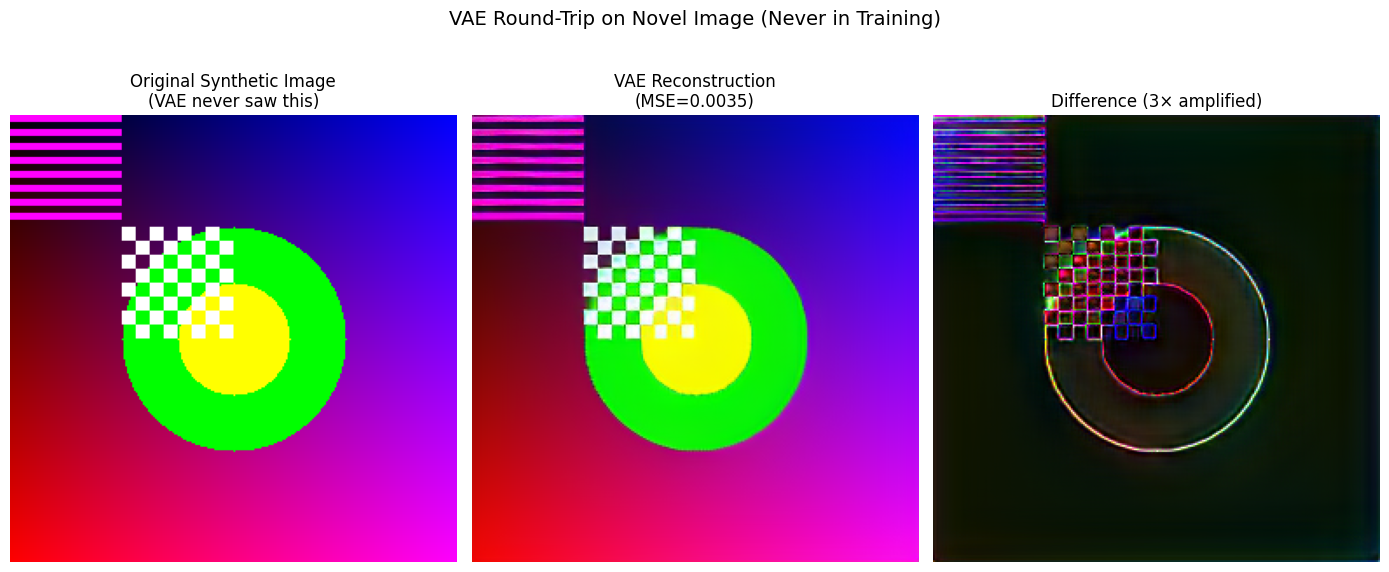

In [15]:
# Create a synthetic test image the VAE has NEVER seen
def create_novel_test_image(size=256):
    """Create a synthetic image with patterns the VAE never saw during training."""
    img = np.zeros((size, size, 3), dtype=np.float32)

    # Gradient background
    for i in range(size):
        img[i, :, 0] = i / size  # Red gradient top to bottom
        img[:, i, 2] = i / size  # Blue gradient left to right

    # Add geometric shapes
    # Circle
    y, x = np.ogrid[:size, :size]
    center = size // 2
    radius = size // 4
    circle_mask = (x - center)**2 + (y - center)**2 <= radius**2
    img[circle_mask] = [0, 1, 0]  # Green circle

    # Smaller circle inside
    inner_radius = size // 8
    inner_mask = (x - center)**2 + (y - center)**2 <= inner_radius**2
    img[inner_mask] = [1, 1, 0]  # Yellow inner circle

    # Add some stripes in corner
    for i in range(0, size//4, 8):
        img[i:i+4, :size//4, :] = [1, 0, 1]  # Magenta stripes

    # Add text-like pattern (checkerboard in corner)
    checker_size = 8
    for i in range(size//4, size//2):
        for j in range(size//4, size//2):
            if ((i // checker_size) + (j // checker_size)) % 2 == 0:
                img[i, j] = [1, 1, 1]  # White

    return torch.from_numpy(img).permute(2, 0, 1).unsqueeze(0)  # [1, 3, H, W]


# Create and process our novel image
novel_image = create_novel_test_image(IMG_SIZE)
print(f"Novel image shape: {novel_image.shape}")

# Encode and decode
novel_latent = encode_to_latents(novel_image, vae)
novel_recon = decode_from_latents(novel_latent, vae)

# Visualize
fig, axes = plt.subplots(1, 3, figsize=(14, 6))

axes[0].imshow(novel_image[0].permute(1, 2, 0).clamp(0, 1))
axes[0].set_title("Original Synthetic Image\n(VAE never saw this)")
axes[0].axis('off')

axes[1].imshow(novel_recon[0].permute(1, 2, 0).clamp(0, 1))
mse = F.mse_loss(novel_image, novel_recon).item()
axes[1].set_title(f"VAE Reconstruction\n(MSE={mse:.4f})")
axes[1].axis('off')

# Difference map
diff = (novel_image - novel_recon).abs()
axes[2].imshow(diff[0].permute(1, 2, 0).clamp(0, 1) * 3)  # Amplify for visibility
axes[2].set_title("Difference (3× amplified)")
axes[2].axis('off')

plt.suptitle("VAE Round-Trip on Novel Image (Never in Training)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

The VAE reconstructs this synthetic image reasonably well,
proving it learned general compression principles, not just memorized training data.
Notice where it struggles: sharp edges, fine patterns, and exact color preservation. Still it is more than enough for our purposes.


So then how do we use these VAEs in our reconstruction pipeline? The idea is simple enough. As you see in the round trip we can both encode images, and decode the latents that come from those images.

During **training**, we encode all stimulus images to get their latent representations. These latents become our regression targets—what we train the brain decoder to predict from fMRI voxels.

During **inference**, the brain decoder predicts latents from new fMRI data, and we pass those predicted latents through the VAE decoder to get reconstructed images:

```
Training:   Stimulus Image → VAE.encode() → Latent (target for regression)
                                                 ↑
                              Brain Decoder learns: Voxels → Latent

Inference:  Voxels → Brain Decoder → Predicted Latent → VAE.decode() → Reconstructed Image
```

## Part 5: Batch Encoding for Larger Datasets

For larger datasets, we need to encode images in batches to avoid running out of GPU memory. These batch functions will be used to encode all NSD images and compute normalization statistics.

In [16]:
# Batch encoding function.

@torch.inference_mode()
def encode_images_batched(
    images: torch.Tensor,
    vae: AutoencoderKL,
    batch_size: int = 16
) -> torch.Tensor:
    """
    Encode images to latents in batches (memory efficient).

    Args:
        images: [N, 3, H, W] tensor
        vae: Loaded VAE model
        batch_size: Batch size for encoding

    Returns:
        latents: [N, 4, H/8, W/8] scaled latents
    """
    scaling_factor = float(vae.config.scaling_factor)
    all_latents = []

    for i in tqdm(range(0, len(images), batch_size), desc="Encoding"):
        batch = images[i:i+batch_size]
        x = to_vae_range(batch).to(device)

        if x.shape[-2:] != (IMG_SIZE, IMG_SIZE):
            x = F.interpolate(x, size=(IMG_SIZE, IMG_SIZE), mode="bilinear", align_corners=False)

        latent_dist = vae.encode(x).latent_dist
        latents = latent_dist.mode() * scaling_factor
        all_latents.append(latents.cpu())

        torch.cuda.empty_cache()

    return torch.cat(all_latents, dim=0)


@torch.inference_mode()
def decode_latents_batched(
    latents: torch.Tensor,
    vae: AutoencoderKL,
    batch_size: int = 16
) -> torch.Tensor:
    """
    Decode latents to images in batches (memory efficient).
    """
    scaling_factor = float(vae.config.scaling_factor)
    all_images = []

    for i in tqdm(range(0, len(latents), batch_size), desc="Decoding"):
        batch = latents[i:i+batch_size]
        z = batch.to(device) / scaling_factor
        x = vae.decode(z).sample
        x = (x.clamp(-1, 1) + 1) / 2
        all_images.append(x.cpu())

        torch.cuda.empty_cache()

    return torch.cat(all_images, dim=0)

Batch encoding/decoding functions defined.


In [17]:
# Encode all loaded NSD images
print(f"Encoding all {len(nsd_images)} NSD images to latents...")
sample_latents = encode_images_batched(nsd_images, vae, batch_size=8)
sample_images = nsd_images

print(f"\nLatents shape: {sample_latents.shape}")
print(f"Latent stats: mean={sample_latents.mean():.4f}, std={sample_latents.std():.4f}")

# Flatten for regression
latents_flat = sample_latents.flatten(1)
print(f"Flattened shape: {latents_flat.shape}")

Encoding all 50 NSD images to latents...


Encoding:   0%|          | 0/7 [00:00<?, ?it/s]


Latents shape: torch.Size([50, 4, 32, 32])
Latent stats: mean=0.0600, std=0.8405
Flattened shape: torch.Size([50, 4096])


## Summary

In this tutorial, we explored **VAE architecture**: the encoder compresses images to a latent distribution, the latent space provides a compact and perceptually meaningful representation (4,096 vs 196,608 dimensions), and the decoder reconstructs images from latents.

We discussed **why SD-VAE latents are useful** for brain decoding: they offer 48× dimensionality reduction, work in a perceptual space where similar images have similar latents, and make regression tractable with limited training samples.

Finally, we demonstrated the **practical workflow**: loading NSD images, encoding/decoding with batch functions, and visualizing the VAE's round-trip reconstruction quality on both real and synthetic images.

**Next Tutorial**: We'll use these latents as regression targets for brain decoding, comparing Ridge regression and MLP approaches creating coarse outputs from our brain data. Let's start with our [Notebook 3: Low-Level Pipeline](https://colab.research.google.com/drive/1nNDbgQF-Z1OzSTJUpr1J_kLhrnOZ3Q4s)